In [17]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [2]:
df =pd.read_csv(r'C:\Users\QC#\Downloads\sales.csv')

In [3]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

## Data Cleaning

In [6]:
df['Item']=df['Item'].replace(['ERROR','UNKNOWN'], np.nan)
df['Item']=df['Item'].fillna('Unknown')
df['Quantity']=pd.to_numeric(df['Quantity'],errors='coerce')
df['Quantity']=df['Quantity'].fillna(df['Quantity'].median())
df['Price Per Unit']=pd.to_numeric(df['Price Per Unit'],errors='coerce')
df['Price Per Unit']=df['Price Per Unit'].fillna(df['Price Per Unit'].median())

In [7]:
df['Total Spent']=pd.to_numeric(df['Total Spent'],errors='coerce')
df['Total Spent']=df['Quantity']*df['Price Per Unit']

In [8]:
df['Payment Method']=df['Payment Method'].replace(['ERROR','UNKNOWN'], np.nan)
df['Payment Method']=df['Payment Method'].fillna('Unknown')
df['Location']=df['Location'].replace(['ERROR','UNKNOWN'], np.nan)
df['Location']=df['Location'].fillna('Unknown')

In [9]:
df=df.sort_values('Transaction ID')
df['Transaction Date']=df['Transaction Date'].replace(['ERROR','UNKNOWN'], np.nan)
df['Transaction Date']=df['Transaction Date'].ffill()
df['Transaction Date']=df['Transaction Date'].bfill()
df['Transaction Date']=pd.to_datetime(df['Transaction Date'])

In [10]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
2987,TXN_1000555,Tea,1.0,1.5,1.5,Credit Card,In-store,2023-10-19
115,TXN_1001832,Salad,2.0,5.0,10.0,Cash,Takeaway,2023-10-19
418,TXN_1002457,Cookie,5.0,1.0,5.0,Digital Wallet,Takeaway,2023-09-29
3417,TXN_1003246,Juice,2.0,3.0,6.0,Unknown,Unknown,2023-02-15
4366,TXN_1004184,Smoothie,1.0,4.0,4.0,Credit Card,In-store,2023-05-18
...,...,...,...,...,...,...,...,...
1389,TXN_9996968,Sandwich,1.0,3.0,3.0,Cash,In-store,2023-10-14
7964,TXN_9997263,Cookie,2.0,1.0,2.0,Unknown,Unknown,2023-03-05
4304,TXN_9997620,Cookie,2.0,1.0,2.0,Cash,Unknown,2023-12-11
98,TXN_9999113,Juice,4.0,3.0,12.0,Cash,Takeaway,2023-05-27


In [11]:
df.isna().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [12]:
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,10000.000000,10000.00000,10000.000000,10000
mean,3.027100,2.95265,8.948150,2023-07-01 07:13:09.120000
min,1.000000,1.00000,1.000000,2023-01-01 00:00:00
25%,2.000000,2.00000,4.000000,2023-03-31 00:00:00
50%,3.000000,3.00000,8.000000,2023-06-30 00:00:00
75%,4.000000,4.00000,12.000000,2023-10-02 00:00:00
max,5.000000,5.00000,25.000000,2023-12-31 00:00:00
std,1.384614,1.24396,5.831191,NaN


In [13]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 10000 entries, 2987 to 5037
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  str           
 1   Item              10000 non-null  str           
 2   Quantity          10000 non-null  float64       
 3   Price Per Unit    10000 non-null  float64       
 4   Total Spent       10000 non-null  float64       
 5   Payment Method    10000 non-null  str           
 6   Location          10000 non-null  str           
 7   Transaction Date  10000 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 703.1 KB
None


In [14]:
#Products By Revenue
product_df=df[df['Item']!='Unknown']
product_rev=product_df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)
product_rev

Item
Salad       16959.0
Sandwich    13538.0
Smoothie    13218.0
Juice       10542.0
Cake        10401.0
Coffee       7261.0
Tea          5296.5
Cookie       3651.0
Name: Total Spent, dtype: float64

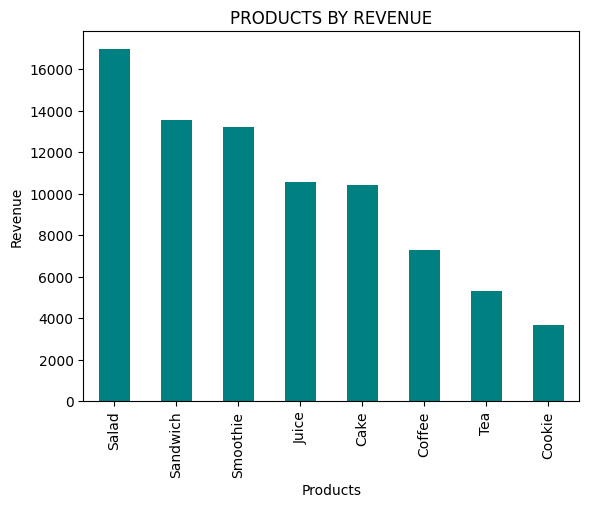

In [15]:
product_rev.plot(kind='bar',color='teal')
plt.title('PRODUCTS BY REVENUE')
plt.xlabel('Products')
plt.ylabel('Revenue')
plt.show()

In [20]:
engine=create_engine('postgresql://#Own path')

In [23]:
df.to_sql('sales_data',con=engine,if_exists='replace',index=False)

1000